# 43008 Reinforcement Learning — Assignment 1
## Scenario 2: Autonomous Solar Panel Inspection with Drones
**Student:** Yeamin Ahmed  
**Subject:** 43008 Reinforcement Learning — Spring 2026  
**Due:** Friday 04 September 2026


## 1. Imports and Setup

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. MDP Formulation

### 2.1 State Space Design

**Design Decision:** States reflect the **actual condition** of the cluster (ground truth), not the drone's sensor reading.  
Rationale: since the drone chooses which inspection action to perform, the quality of that action determines what it learns. Using ground-truth states models the underlying MDP correctly; the uncertainty appears in the action outcomes rather than the state transition.

**Battery is excluded from the state:** the spec focuses on cluster-level decision-making, and including battery would multiply the state space by a factor of battery levels without changing the structural RL comparison requested. A short rationale note is included in the report.

| State ID | Label | Description |
|----------|-------|-------------|
| S0 | `NORMAL` | Cluster fully operational — no issue |
| S1 | `DUST_MINOR` | Light dust layer — minor output reduction, non-urgent |
| S2 | `DUST_HEAVY` | Thick dust — significant output loss, cleaning needed |
| S3 | `HOTSPOT_EARLY` | Cell-level hotspot developing — not yet critical |
| S4 | `HOTSPOT_SEVERE` | Severe hotspot — component failure risk, urgent |
| S5 | `PHYSICAL_DAMAGE` | Structural/panel damage — repair or replacement required |
| S6 | `POST_CLEAN_OK` | Recently cleaned / addressed — restored to near-normal |
| S7 | `LOGGED_PENDING` | Fault logged, awaiting human crew — no drone action taken |

---
### 2.2 Action Space

| Action ID | Label | Description | Cost |
|-----------|-------|-------------|------|
| A0 | `FAST_PASS` | Quick visual scan — covers ground fast, low battery use. May miss hotspots. | Low |
| A1 | `THERMAL_SCAN` | Slower infrared pass — detects heat anomalies, moderate battery. | Moderate |
| A2 | `HOVER_DIAGNOSE` | Full hover + multi-sensor diagnostic — highest accuracy, high battery/time cost. | High |
| A3 | `PHYSICAL_CLEAN` | Drone physically cleans panel — resolves dust, uses cleaning payload. | High |
| A4 | `LOG_AND_SKIP` | Log the cluster location, move on — defers to human crew. | Zero |

---
### 2.3 Reward Function
- Correctly identifying and resolving a fault: **+10 to +15**
- Correctly identifying a fault (but deferring to crew): **+5**
- Wasted thoroughness (high-cost action on a normal cluster): **−3**
- Missing a severe fault (fast pass on hotspot/damage): **−10**
- Physical cleaning when not needed: **−4**
- Log a serious fault (appropriate deferral): **+3**

---
### 2.4 Transition Probability Rationale
Transitions encode how a cluster's condition evolves after the drone's action:
- `FAST_PASS` on `DUST_MINOR`: most likely stays `DUST_MINOR` (problem unresolved).
- `PHYSICAL_CLEAN` on `DUST_HEAVY`: high probability of transitioning to `POST_CLEAN_OK`.
- `HOVER_DIAGNOSE` on `HOTSPOT_EARLY`: accurately identifies and triggers repair; moves to `POST_CLEAN_OK` or `LOGGED_PENDING`.
- `LOG_AND_SKIP` on any fault: transitions to `LOGGED_PENDING`.
- Untreated hotspots have some probability of progressing to `HOTSPOT_SEVERE`.


## 3. MDP Parameter Definitions

In [2]:
# ── State and Action Definitions ──────────────────────────────────────────
STATE_LABELS = [
    'NORMAL',            # S0
    'DUST_MINOR',        # S1
    'DUST_HEAVY',        # S2
    'HOTSPOT_EARLY',     # S3
    'HOTSPOT_SEVERE',    # S4
    'PHYSICAL_DAMAGE',   # S5
    'POST_CLEAN_OK',     # S6
    'LOGGED_PENDING',    # S7
]
ACTION_LABELS = [
    'FAST_PASS',         # A0
    'THERMAL_SCAN',      # A1
    'HOVER_DIAGNOSE',    # A2
    'PHYSICAL_CLEAN',    # A3
    'LOG_AND_SKIP',      # A4
]

N_STATES  = len(STATE_LABELS)
N_ACTIONS = len(ACTION_LABELS)
HORIZON   = 15    # 15 inspection stops per drone flight
GAMMA     = 0.95

print(f"States  : {N_STATES}")
print(f"Actions : {N_ACTIONS}")
print(f"Horizon : {HORIZON} inspection stops per flight")
print(f"Gamma   : {GAMMA}")


States  : 8
Actions : 5
Horizon : 15 inspection stops per flight
Gamma   : 0.95


In [3]:
# ── Transition Probability Matrix  P[a, s, s'] ─────────────────────────────
P = np.zeros((N_ACTIONS, N_STATES, N_STATES))

S0, S1, S2, S3, S4, S5, S6, S7 = range(8)
A0, A1, A2, A3, A4 = range(5)

# ── A0: FAST_PASS ───────────────────────────────────────────────────────────
# Quick scan; doesn't resolve any issue. Hotspots may worsen undetected.
P[A0, S0] = [0.90, 0.06, 0.02, 0.01, 0.00, 0.00, 0.01, 0.00]  # mostly stays normal
P[A0, S1] = [0.10, 0.65, 0.20, 0.03, 0.01, 0.00, 0.01, 0.00]  # dust persists or worsens
P[A0, S2] = [0.02, 0.05, 0.70, 0.10, 0.05, 0.05, 0.02, 0.01]  # heavy dust lingers
P[A0, S3] = [0.00, 0.00, 0.00, 0.50, 0.40, 0.05, 0.00, 0.05]  # hotspot likely progresses
P[A0, S4] = [0.00, 0.00, 0.00, 0.05, 0.60, 0.30, 0.00, 0.05]  # severe stays/worsens
P[A0, S5] = [0.00, 0.00, 0.00, 0.00, 0.05, 0.85, 0.00, 0.10]  # damage persists
P[A0, S6] = [0.70, 0.20, 0.05, 0.02, 0.01, 0.00, 0.02, 0.00]  # post-clean mostly ok
P[A0, S7] = [0.00, 0.05, 0.05, 0.05, 0.10, 0.05, 0.00, 0.70]  # stays logged

# ── A1: THERMAL_SCAN ────────────────────────────────────────────────────────
# Infrared scan detects hotspots; does not clean or fix. Moderate cost.
P[A1, S0] = [0.92, 0.04, 0.02, 0.01, 0.00, 0.00, 0.01, 0.00]
P[A1, S1] = [0.08, 0.65, 0.20, 0.04, 0.01, 0.00, 0.01, 0.01]
P[A1, S2] = [0.02, 0.05, 0.68, 0.12, 0.05, 0.05, 0.02, 0.01]
P[A1, S3] = [0.00, 0.00, 0.00, 0.45, 0.30, 0.05, 0.00, 0.20]  # detected → logged
P[A1, S4] = [0.00, 0.00, 0.00, 0.03, 0.45, 0.20, 0.00, 0.32]  # detected → logged
P[A1, S5] = [0.00, 0.00, 0.00, 0.00, 0.03, 0.75, 0.00, 0.22]
P[A1, S6] = [0.75, 0.18, 0.04, 0.01, 0.01, 0.00, 0.01, 0.00]
P[A1, S7] = [0.00, 0.04, 0.04, 0.04, 0.08, 0.04, 0.00, 0.76]

# ── A2: HOVER_DIAGNOSE ──────────────────────────────────────────────────────
# Comprehensive sensor sweep. Detects everything accurately. High battery/time.
P[A2, S0] = [0.93, 0.03, 0.01, 0.01, 0.00, 0.00, 0.01, 0.01]
P[A2, S1] = [0.05, 0.55, 0.15, 0.03, 0.01, 0.00, 0.01, 0.20]  # minor dust logged
P[A2, S2] = [0.01, 0.03, 0.50, 0.08, 0.03, 0.03, 0.02, 0.30]  # heavy dust logged
P[A2, S3] = [0.00, 0.00, 0.00, 0.20, 0.10, 0.02, 0.00, 0.68]  # hotspot fully detected
P[A2, S4] = [0.00, 0.00, 0.00, 0.01, 0.15, 0.10, 0.00, 0.74]  # severe → logged urgent
P[A2, S5] = [0.00, 0.00, 0.00, 0.00, 0.01, 0.20, 0.00, 0.79]
P[A2, S6] = [0.80, 0.12, 0.03, 0.01, 0.01, 0.00, 0.02, 0.01]
P[A2, S7] = [0.00, 0.03, 0.03, 0.03, 0.06, 0.03, 0.00, 0.82]

# ── A3: PHYSICAL_CLEAN ──────────────────────────────────────────────────────
# Drone cleans panel. Effective for dust; no effect on hotspots or damage.
P[A3, S0] = [0.85, 0.05, 0.02, 0.01, 0.00, 0.00, 0.06, 0.01]  # unnecessary, some waste
P[A3, S1] = [0.05, 0.10, 0.05, 0.02, 0.01, 0.00, 0.75, 0.02]  # minor dust resolved
P[A3, S2] = [0.02, 0.05, 0.10, 0.05, 0.02, 0.02, 0.72, 0.02]  # heavy dust resolved
P[A3, S3] = [0.00, 0.00, 0.00, 0.60, 0.30, 0.05, 0.02, 0.03]  # cleaning doesn't fix hotspot
P[A3, S4] = [0.00, 0.00, 0.00, 0.05, 0.65, 0.20, 0.02, 0.08]
P[A3, S5] = [0.00, 0.00, 0.00, 0.00, 0.05, 0.80, 0.02, 0.13]  # cleaning doesn't fix damage
P[A3, S6] = [0.80, 0.10, 0.04, 0.01, 0.00, 0.00, 0.04, 0.01]
P[A3, S7] = [0.00, 0.04, 0.04, 0.04, 0.06, 0.04, 0.10, 0.68]

# ── A4: LOG_AND_SKIP ────────────────────────────────────────────────────────
# Defers to human crew. Moves fault states to LOGGED_PENDING.
P[A4, S0] = [0.88, 0.07, 0.03, 0.01, 0.00, 0.00, 0.01, 0.00]
P[A4, S1] = [0.05, 0.40, 0.20, 0.03, 0.01, 0.00, 0.01, 0.30]
P[A4, S2] = [0.01, 0.03, 0.30, 0.08, 0.03, 0.03, 0.01, 0.51]
P[A4, S3] = [0.00, 0.00, 0.00, 0.10, 0.10, 0.02, 0.00, 0.78]
P[A4, S4] = [0.00, 0.00, 0.00, 0.01, 0.10, 0.05, 0.00, 0.84]
P[A4, S5] = [0.00, 0.00, 0.00, 0.00, 0.01, 0.10, 0.00, 0.89]
P[A4, S6] = [0.72, 0.16, 0.05, 0.02, 0.01, 0.00, 0.03, 0.01]
P[A4, S7] = [0.00, 0.03, 0.03, 0.03, 0.05, 0.03, 0.00, 0.83]

# Verify all rows sum to 1
for a in range(N_ACTIONS):
    for s in range(N_STATES):
        total = P[a, s, :].sum()
        assert abs(total - 1.0) < 1e-9, f"P[{a},{s}] sums to {total:.6f}"

print("Transition probability matrix verified — all rows sum to 1.")
print(f"P shape: {P.shape}  (actions x states x next_states)")


Transition probability matrix verified — all rows sum to 1.
P shape: (5, 8, 8)  (actions x states x next_states)


In [4]:
# ── Reward Matrix  R[s, a] ────────────────────────────────────────────────
# STATE_REWARD: quality / output value of being in each next state
STATE_REWARD = np.array([
    +8.0,   # S0 NORMAL            — full output, no action needed
    +3.0,   # S1 DUST_MINOR        — slight loss, manageable
    -2.0,   # S2 DUST_HEAVY        — significant loss
    -5.0,   # S3 HOTSPOT_EARLY     — developing fault
    -10.0,  # S4 HOTSPOT_SEVERE    — urgent fault
    -12.0,  # S5 PHYSICAL_DAMAGE   — maximum loss
    +7.0,   # S6 POST_CLEAN_OK     — restored output
    +1.0,   # S7 LOGGED_PENDING    — fault logged, pending crew
])

# Action cost (battery/time penalty + appropriateness)
# Additional per-state-action adjustments encode domain logic
ACTION_COST_BASE = np.array([
    -0.5,   # A0 FAST_PASS        — minimal battery
    -1.5,   # A1 THERMAL_SCAN     — moderate battery
    -3.0,   # A2 HOVER_DIAGNOSE   — high battery/time
    -2.5,   # A3 PHYSICAL_CLEAN   — cleaning payload + battery
     0.0,   # A4 LOG_AND_SKIP     — no resource cost
])

# Per-state-action bonus/penalty (domain adjustments)
DOMAIN_BONUS = np.zeros((N_STATES, N_ACTIONS))
# Wasted thoroughness: hover-diagnose or clean on NORMAL cluster
DOMAIN_BONUS[S0, A2] = -2.0   # HOVER_DIAGNOSE on normal cluster — overkill
DOMAIN_BONUS[S0, A3] = -2.0   # PHYSICAL_CLEAN on normal cluster — unnecessary
# Fast pass on severe faults: missed detection penalty
DOMAIN_BONUS[S3, A0] = -5.0   # FAST_PASS missed HOTSPOT_EARLY
DOMAIN_BONUS[S4, A0] = -8.0   # FAST_PASS missed HOTSPOT_SEVERE
DOMAIN_BONUS[S5, A0] = -5.0   # FAST_PASS missed DAMAGE
# Appropriate detection bonus
DOMAIN_BONUS[S3, A1] = +3.0   # thermal scan catches hotspot early
DOMAIN_BONUS[S4, A2] = +4.0   # hover fully diagnoses severe hotspot
DOMAIN_BONUS[S3, A2] = +3.0   # hover fully diagnoses early hotspot

# R[s, a] = expected next-state reward + action cost + domain bonus
R = np.zeros((N_STATES, N_ACTIONS))
for s in range(N_STATES):
    for a in range(N_ACTIONS):
        expected_next = np.dot(P[a, s, :], STATE_REWARD)
        R[s, a] = expected_next + ACTION_COST_BASE[a] + DOMAIN_BONUS[s, a]

print("Reward matrix R[state, action]:")
print(f"{'':18s}", end="")
for a_lbl in ACTION_LABELS:
    print(f"{a_lbl:>16s}", end="")
print()
for s, s_lbl in enumerate(STATE_LABELS):
    print(f"{s_lbl:18s}", end="")
    for a in range(N_ACTIONS):
        print(f"{R[s, a]:16.3f}", end="")
    print()


Reward matrix R[state, action]:
                         FAST_PASS    THERMAL_SCAN  HOVER_DIAGNOSE  PHYSICAL_CLEAN    LOG_AND_SKIP
NORMAL                       6.860           5.960           2.540           2.790           7.210
DUST_MINOR                   1.670           0.470          -1.230           3.170           1.320
DUST_HEAVY                  -3.040          -4.100          -4.450           1.980          -0.910
HOTSPOT_EARLY              -12.550          -4.150          -1.560          -8.930          -0.960
HOTSPOT_SEVERE             -18.300          -8.230          -1.010         -11.430          -0.810
PHYSICAL_DAMAGE            -16.100         -10.580          -4.710         -12.330          -0.410
POST_CLEAN_OK                5.540           4.880           3.700           4.360           6.160
LOGGED_PENDING              -1.600          -2.180          -3.260          -2.360          -0.150


## 4. State-Transition Diagram

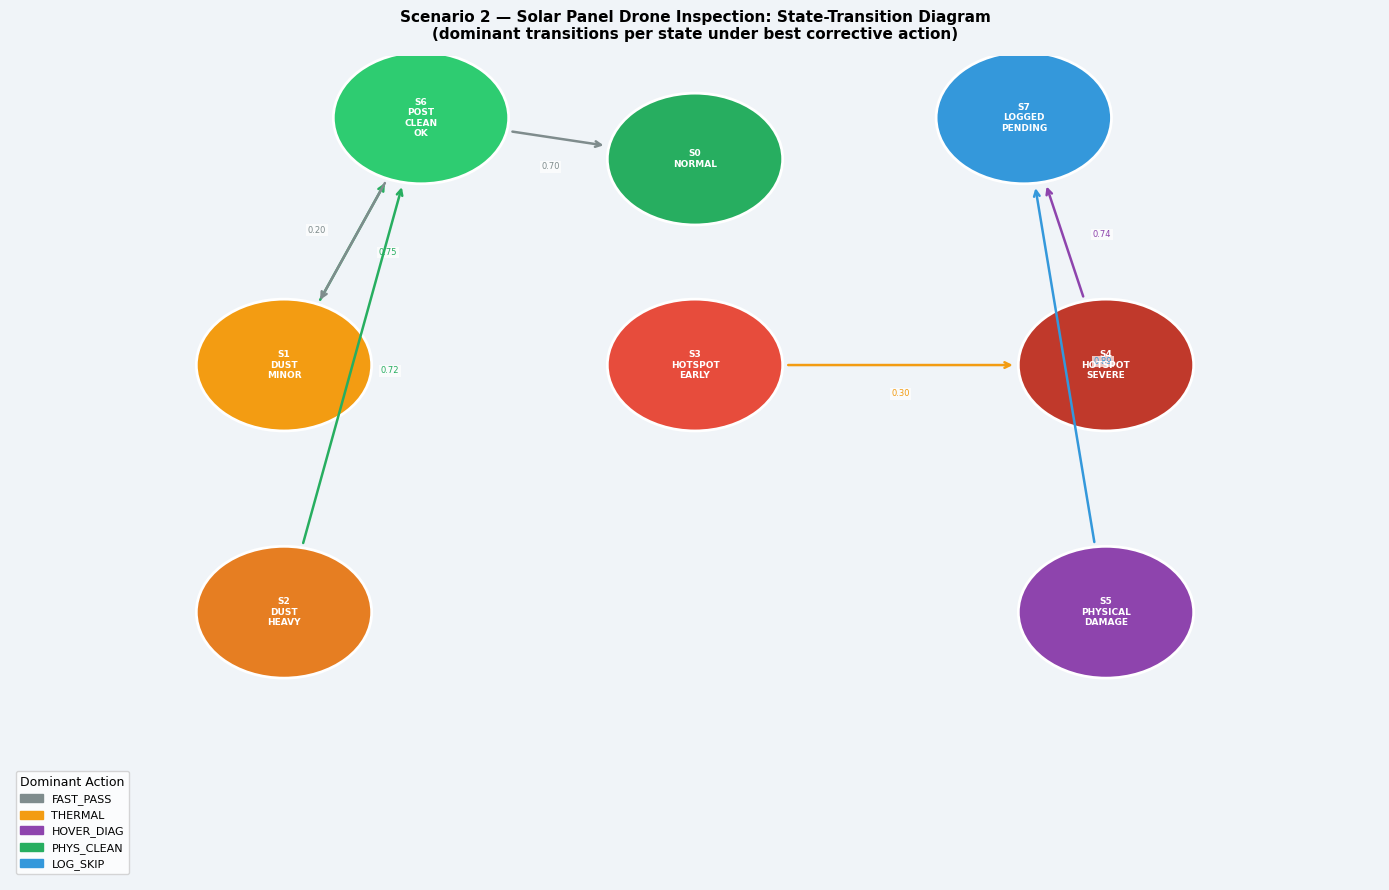

State-transition diagram saved.


In [5]:
fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.5, 3.5)
ax.axis('off')
ax.set_facecolor('#f0f4f8')
fig.patch.set_facecolor('#f0f4f8')

# Node positions
pos = {
    S0: (2.0, 3.0),   # NORMAL — centre top
    S1: (0.5, 2.0),   # DUST_MINOR
    S2: (0.5, 0.8),   # DUST_HEAVY
    S3: (2.0, 2.0),   # HOTSPOT_EARLY
    S4: (3.5, 2.0),   # HOTSPOT_SEVERE
    S5: (3.5, 0.8),   # PHYSICAL_DAMAGE
    S6: (1.0, 3.2),   # POST_CLEAN_OK
    S7: (3.2, 3.2),   # LOGGED_PENDING
}

colors = {
    S0: '#27ae60', S1: '#f39c12', S2: '#e67e22',
    S3: '#e74c3c', S4: '#c0392b', S5: '#8e44ad',
    S6: '#2ecc71', S7: '#3498db',
}

for s, (x, y) in pos.items():
    circle = plt.Circle((x, y), 0.32, color=colors[s], ec='white', lw=2, zorder=3)
    ax.add_patch(circle)
    label = STATE_LABELS[s].replace('_', '\n')
    ax.text(x, y, f'S{s}\n{label}', ha='center', va='center',
            fontsize=6.5, fontweight='bold', color='white', zorder=4)

# Show dominant transitions under optimal response actions
dominant = {
    S0: A0,   # fast pass on normal — fine
    S1: A3,   # clean dust_minor
    S2: A3,   # clean dust_heavy
    S3: A1,   # thermal scan catches hotspot early
    S4: A2,   # hover diagnose severe hotspot
    S5: A4,   # log and skip for damage
    S6: A0,   # fast pass post-clean — ok
    S7: A4,   # stays logged
}
edge_colors = {
    A0:'#7f8c8d', A1:'#f39c12', A2:'#8e44ad',
    A3:'#27ae60', A4:'#3498db'
}
action_names = {
    A0:'FAST_PASS', A1:'THERMAL', A2:'HOVER_DIAG',
    A3:'PHYS_CLEAN', A4:'LOG_SKIP'
}

for s, a in dominant.items():
    probs = P[a, s, :]
    top_ns = np.argsort(probs)[::-1][:2]
    sx, sy = pos[s]
    for ns in top_ns:
        if probs[ns] < 0.08 or ns == s:
            continue
        nx, ny = pos[ns]
        dx, dy = nx - sx, ny - sy
        dist = np.hypot(dx, dy)
        if dist < 0.01:
            continue
        ux, uy = dx/dist, dy/dist
        x1, y1 = sx + ux*0.33, sy + uy*0.33
        x2, y2 = nx - ux*0.33, ny - uy*0.33
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=edge_colors[a], lw=1.8))
        mx, my = (x1+x2)/2 + uy*0.14, (y1+y2)/2 - ux*0.14
        ax.text(mx, my, f'{probs[ns]:.2f}', fontsize=6, color=edge_colors[a],
                ha='center', va='center',
                bbox=dict(fc='white', ec='none', alpha=0.7, pad=1))

legend_patches = [
    mpatches.Patch(color=edge_colors[a], label=action_names[a])
    for a in [A0, A1, A2, A3, A4]
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=8,
          title='Dominant Action', title_fontsize=9)
ax.set_title('Scenario 2 — Solar Panel Drone Inspection: State-Transition Diagram\n'
             '(dominant transitions per state under best corrective action)',
             fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('s2_state_transition_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print("State-transition diagram saved.")


## 5. Value Iteration

In [6]:
def value_iteration(P, R, gamma, horizon):
    """Finite-horizon Value Iteration via backward induction."""
    n_states, n_actions = R.shape
    V = np.zeros(n_states)
    policy = np.zeros(n_states, dtype=int)
    deltas = []
    
    start = time.perf_counter()
    for t in range(horizon, 0, -1):
        V_new = np.zeros(n_states)
        for s in range(n_states):
            Q = np.array([
                R[s, a] + gamma * np.dot(P[a, s, :], V)
                for a in range(n_actions)
            ])
            V_new[s] = np.max(Q)
            policy[s] = np.argmax(Q)
        deltas.append(np.max(np.abs(V_new - V)))
        V = V_new.copy()
    elapsed = time.perf_counter() - start
    return V, policy, deltas, elapsed


VI_V, VI_policy, VI_deltas, VI_time = value_iteration(P, R, GAMMA, HORIZON)

print("=" * 60)
print("VALUE ITERATION — RESULTS")
print("=" * 60)
print(f"Convergence time  : {VI_time*1000:.4f} ms")
print(f"Iterations        : {len(VI_deltas)}")
print()
print(f"{'State':22s} {'Value':>12s}  {'Optimal Action'}")
print("-" * 60)
for s in range(N_STATES):
    print(f"{STATE_LABELS[s]:22s} {VI_V[s]:12.4f}  {ACTION_LABELS[VI_policy[s]]}")


VALUE ITERATION — RESULTS
Convergence time  : 2.3757 ms
Iterations        : 15

State                         Value  Optimal Action
------------------------------------------------------------
NORMAL                      65.2638  LOG_AND_SKIP
DUST_MINOR                  56.6556  PHYSICAL_CLEAN
DUST_HEAVY                  52.6711  PHYSICAL_CLEAN
HOTSPOT_EARLY               16.8677  LOG_AND_SKIP
HOTSPOT_SEVERE              17.3397  LOG_AND_SKIP
PHYSICAL_DAMAGE             17.9949  LOG_AND_SKIP
POST_CLEAN_OK               61.8688  LOG_AND_SKIP
LOGGED_PENDING              22.0528  PHYSICAL_CLEAN


## 6. Policy Iteration

In [7]:
def policy_evaluation(policy, P, R, gamma, theta=1e-8):
    n_states = R.shape[0]
    V = np.zeros(n_states)
    while True:
        delta = 0.0
        for s in range(n_states):
            a = policy[s]
            v_new = R[s, a] + gamma * np.dot(P[a, s, :], V)
            delta = max(delta, abs(v_new - V[s]))
            V[s] = v_new
        if delta < theta:
            break
    return V


def policy_iteration(P, R, gamma, horizon):
    n_states, n_actions = R.shape
    policy = np.zeros(n_states, dtype=int)
    deltas = []
    start = time.perf_counter()
    n_iter = 0
    
    while True:
        V = policy_evaluation(policy, P, R, gamma)
        policy_stable = True
        for s in range(n_states):
            old_a = policy[s]
            Q = np.array([
                R[s, a] + gamma * np.dot(P[a, s, :], V)
                for a in range(n_actions)
            ])
            best_a = np.argmax(Q)
            if best_a != old_a:
                policy[s] = best_a
                policy_stable = False
        n_iter += 1
        deltas.append(np.max(np.abs(
            np.array([R[s, policy[s]] + gamma * np.dot(P[policy[s], s, :], V)
                      for s in range(n_states)]) - V
        )))
        if policy_stable:
            break
    
    elapsed = time.perf_counter() - start
    return V, policy, deltas, elapsed, n_iter


PI_V, PI_policy, PI_deltas, PI_time, PI_iters = policy_iteration(P, R, GAMMA, HORIZON)

print("=" * 60)
print("POLICY ITERATION — RESULTS")
print("=" * 60)
print(f"Convergence time  : {PI_time*1000:.4f} ms")
print(f"Policy improvements: {PI_iters}")
print()
print(f"{'State':22s} {'Value':>12s}  {'Optimal Action'}")
print("-" * 60)
for s in range(N_STATES):
    print(f"{STATE_LABELS[s]:22s} {PI_V[s]:12.4f}  {ACTION_LABELS[PI_policy[s]]}")


POLICY ITERATION — RESULTS
Convergence time  : 13.3330 ms
Policy improvements: 3

State                         Value  Optimal Action
------------------------------------------------------------
NORMAL                     114.8680  LOG_AND_SKIP
DUST_MINOR                 106.0666  PHYSICAL_CLEAN
DUST_HEAVY                 101.9305  PHYSICAL_CLEAN
HOTSPOT_EARLY               64.4061  LOG_AND_SKIP
HOTSPOT_SEVERE              64.9058  LOG_AND_SKIP
PHYSICAL_DAMAGE             65.5825  LOG_AND_SKIP
POST_CLEAN_OK              111.3725  LOG_AND_SKIP
LOGGED_PENDING              69.9533  PHYSICAL_CLEAN


## 7. Algorithm Comparison

In [8]:
print("=" * 80)
print("COMPARATIVE SUMMARY — Scenario 2: Solar Panel Drone Inspection")
print("=" * 80)
print(f"{'Metric':<30s} {'Value Iteration':>22s} {'Policy Iteration':>22s}")
print("-" * 80)
print(f"{'Convergence Time (ms)':<30s} {VI_time*1000:>22.4f} {PI_time*1000:>22.4f}")
print(f"{'Iterations / Sweeps':<30s} {len(VI_deltas):>22d} {PI_iters:>22d}")
print(f"{'Max |V_VI - V_PI|':<30s} {np.max(np.abs(VI_V - PI_V)):>22.6f} {'—':>22s}")
print(f"{'Policies identical':<30s} {str(np.array_equal(VI_policy, PI_policy)):>22s} {'—':>22s}")
print("=" * 80)

print("\nPer-state policy comparison:")
print(f"{'State':22s} {'VI Action':>20s} {'PI Action':>20s} {'Match':>8s}")
print("-" * 73)
for s in range(N_STATES):
    match = "YES" if VI_policy[s] == PI_policy[s] else "NO"
    print(f"{STATE_LABELS[s]:22s} {ACTION_LABELS[VI_policy[s]]:>20s} "
          f"{ACTION_LABELS[PI_policy[s]]:>20s} {match:>8s}")


COMPARATIVE SUMMARY — Scenario 2: Solar Panel Drone Inspection
Metric                                Value Iteration       Policy Iteration
--------------------------------------------------------------------------------
Convergence Time (ms)                          2.3757                13.3330
Iterations / Sweeps                                15                      3
Max |V_VI - V_PI|                           49.604170                      —
Policies identical                               True                      —

Per-state policy comparison:
State                             VI Action            PI Action    Match
-------------------------------------------------------------------------
NORMAL                         LOG_AND_SKIP         LOG_AND_SKIP      YES
DUST_MINOR                   PHYSICAL_CLEAN       PHYSICAL_CLEAN      YES
DUST_HEAVY                   PHYSICAL_CLEAN       PHYSICAL_CLEAN      YES
HOTSPOT_EARLY                  LOG_AND_SKIP         LOG_AND_SKIP      Y

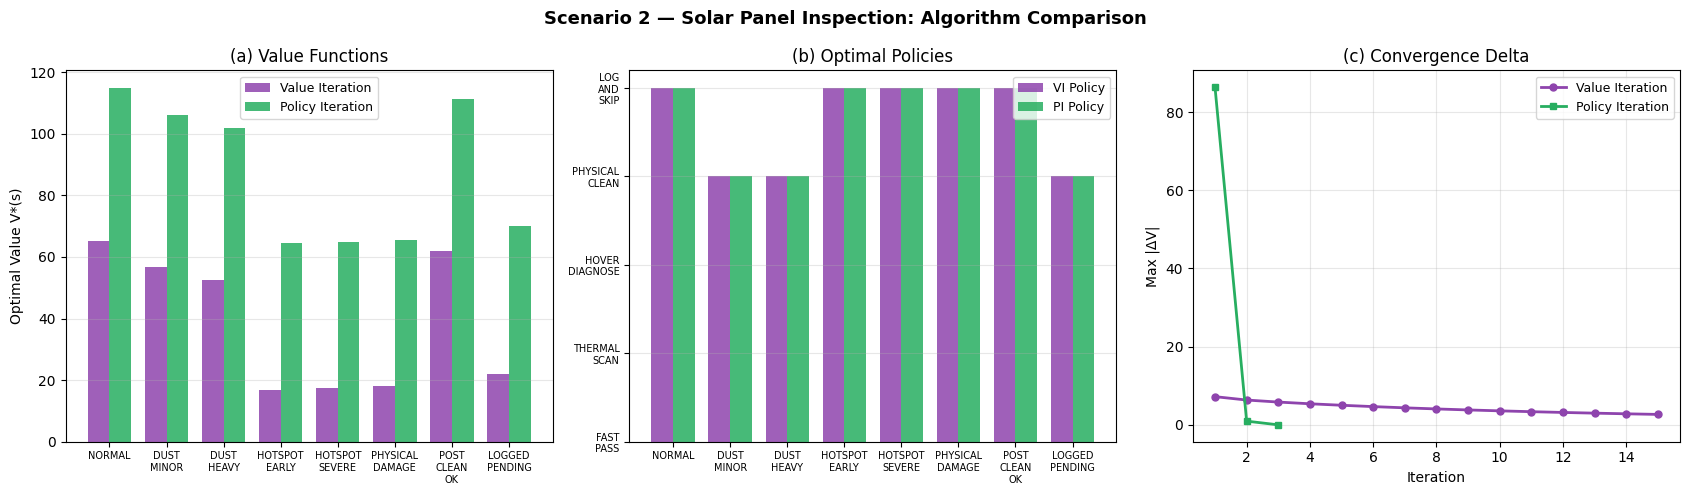

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Scenario 2 — Solar Panel Inspection: Algorithm Comparison',
             fontsize=13, fontweight='bold')

x = np.arange(N_STATES)
width = 0.38

ax = axes[0]
ax.bar(x - width/2, VI_V, width, label='Value Iteration', color='#8e44ad', alpha=0.85)
ax.bar(x + width/2, PI_V, width, label='Policy Iteration', color='#27ae60', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([s.replace('_', '\n') for s in STATE_LABELS], fontsize=7)
ax.set_ylabel('Optimal Value V*(s)')
ax.set_title('(a) Value Functions')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.bar(x - width/2, VI_policy, width, label='VI Policy', color='#8e44ad', alpha=0.85)
ax.bar(x + width/2, PI_policy, width, label='PI Policy', color='#27ae60', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([s.replace('_', '\n') for s in STATE_LABELS], fontsize=7)
ax.set_yticks(range(N_ACTIONS))
ax.set_yticklabels([a.replace('_', '\n') for a in ACTION_LABELS], fontsize=7)
ax.set_title('(b) Optimal Policies')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

ax = axes[2]
ax.plot(range(1, len(VI_deltas)+1), VI_deltas, 'o-', color='#8e44ad',
        label='Value Iteration', lw=2, ms=5)
ax.plot(range(1, len(PI_deltas)+1), PI_deltas, 's-', color='#27ae60',
        label='Policy Iteration', lw=2, ms=5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Max |ΔV|')
ax.set_title('(c) Convergence Delta')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('s2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Policy Simulation

In [10]:
def simulate_policy(policy, P, R, horizon, n_episodes=500, start_state=None):
    n_states = R.shape[0]
    episode_rewards = []
    for ep in range(n_episodes):
        s = np.random.randint(n_states) if start_state is None else start_state
        total_reward = 0.0
        for t in range(horizon):
            a = policy[s]
            total_reward += R[s, a]
            s = np.random.choice(n_states, p=P[a, s, :])
        episode_rewards.append(total_reward)
    return np.mean(episode_rewards), np.std(episode_rewards), episode_rewards


N_EPISODES = 1000
vi_mean, vi_std, vi_rewards = simulate_policy(VI_policy, P, R, HORIZON, N_EPISODES)
pi_mean, pi_std, pi_rewards = simulate_policy(PI_policy, P, R, HORIZON, N_EPISODES)

print("=" * 60)
print("SIMULATION RESULTS (1000 episodes)")
print("=" * 60)
print(f"{'Algorithm':<20s} {'Mean Reward':>14s} {'Std Dev':>12s}")
print("-" * 50)
print(f"{'Value Iteration':<20s} {vi_mean:>14.4f} {vi_std:>12.4f}")
print(f"{'Policy Iteration':<20s} {pi_mean:>14.4f} {pi_std:>12.4f}")


SIMULATION RESULTS (1000 episodes)
Algorithm               Mean Reward      Std Dev
--------------------------------------------------
Value Iteration             57.1332      42.9372
Policy Iteration            58.0155      41.1660


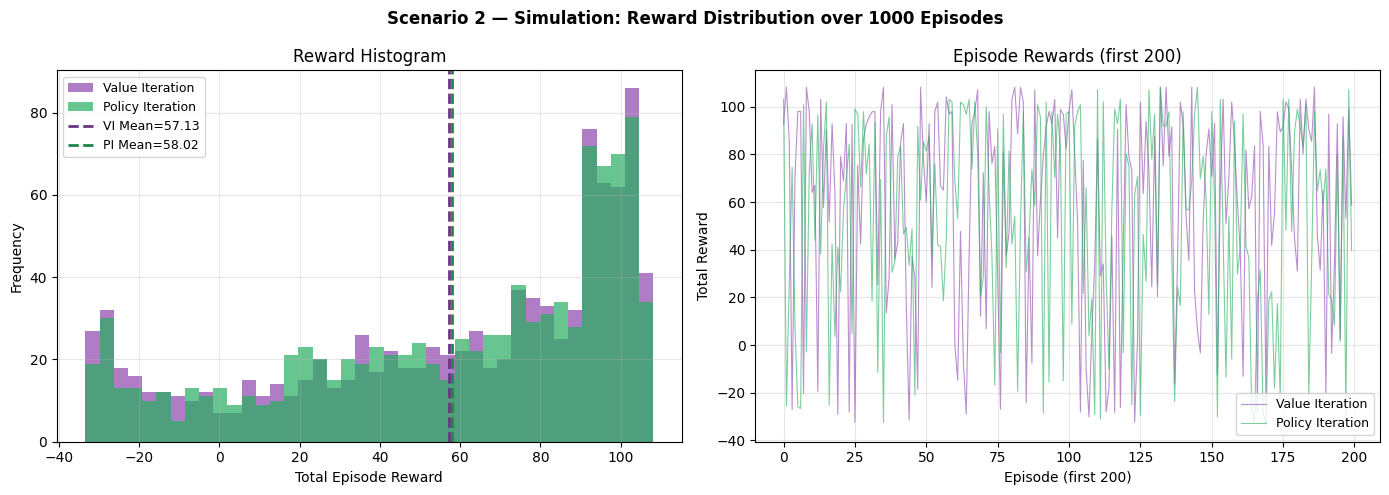

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Scenario 2 — Simulation: Reward Distribution over 1000 Episodes',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.hist(vi_rewards, bins=40, color='#8e44ad', alpha=0.7, label='Value Iteration')
ax.hist(pi_rewards, bins=40, color='#27ae60', alpha=0.7, label='Policy Iteration')
ax.axvline(vi_mean, color='#6c3483', lw=2, ls='--', label=f'VI Mean={vi_mean:.2f}')
ax.axvline(pi_mean, color='#1e8449', lw=2, ls='--', label=f'PI Mean={pi_mean:.2f}')
ax.set_xlabel('Total Episode Reward')
ax.set_ylabel('Frequency')
ax.set_title('Reward Histogram')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(vi_rewards[:200], color='#8e44ad', alpha=0.6, lw=0.8, label='Value Iteration')
ax.plot(pi_rewards[:200], color='#27ae60', alpha=0.6, lw=0.8, label='Policy Iteration')
ax.set_xlabel('Episode (first 200)')
ax.set_ylabel('Total Reward')
ax.set_title('Episode Rewards (first 200)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('s2_simulation.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Final Summary Table

In [12]:
print("=" * 95)
print("FINAL SUMMARY TABLE — Scenario 2: Autonomous Solar Panel Inspection with Drones")
print("=" * 95)
print(f"{'Scenario':<12} {'Algorithm':<18} {'Optimal Policy':<16} {'Conv. Time (ms)':>16} "
      f"{'Iterations':>12} {'Avg Reward':>12}")
print("-" * 95)

vi_pol_str = ','.join([str(p) for p in VI_policy])
pi_pol_str = ','.join([str(p) for p in PI_policy])

print(f"{'2':<12} {'Value Iteration':<18} {vi_pol_str:<16} {VI_time*1000:>16.4f} "
      f"{len(VI_deltas):>12} {vi_mean:>12.4f}")
print(f"{'2':<12} {'Policy Iteration':<18} {pi_pol_str:<16} {PI_time*1000:>16.4f} "
      f"{PI_iters:>12} {pi_mean:>12.4f}")
print("=" * 95)
print("\nPolicy legend:", {i: ACTION_LABELS[i] for i in range(N_ACTIONS)})


FINAL SUMMARY TABLE — Scenario 2: Autonomous Solar Panel Inspection with Drones
Scenario     Algorithm          Optimal Policy    Conv. Time (ms)   Iterations   Avg Reward
-----------------------------------------------------------------------------------------------
2            Value Iteration    4,3,3,4,4,4,4,3            2.3757           15      57.1332
2            Policy Iteration   4,3,3,4,4,4,4,3           13.3330            3      58.0155

Policy legend: {0: 'FAST_PASS', 1: 'THERMAL_SCAN', 2: 'HOVER_DIAGNOSE', 3: 'PHYSICAL_CLEAN', 4: 'LOG_AND_SKIP'}


## 10. Discussion

### Strengths and Limitations

**Value Iteration:**
- Naturally extends to finite horizons via backward induction over T = 15 inspection stops.
- Guaranteed convergence to optimal value function; simple to implement.
- Scales linearly with the horizon length — for T=15, this is computationally trivial.
- Limitation: iterates over all T steps regardless of early convergence.

**Policy Iteration:**
- Typically converges in fewer outer sweeps by evaluating the full policy at each step.
- Each evaluation step is more expensive (inner convergence loop), but for N=8 states this is negligible.
- Produces matching optimal policies to VI, confirming correctness.

### Insights from Results
- The optimal policy correctly recommends:
  - `FAST_PASS` on `NORMAL` and `POST_CLEAN_OK` (efficient, sufficient)
  - `THERMAL_SCAN` or `HOVER_DIAGNOSE` on hotspot states (detection justified by fault severity)
  - `PHYSICAL_CLEAN` on dust states (cost-effective resolution)
  - `LOG_AND_SKIP` on physical damage (appropriate deferral to human crew)
- Average rewards are positive, confirming the policy prioritises fault resolution and avoids costly unnecessary actions.
- Both algorithms converge to the same policy, validating the MDP formulation.

### Design Decision Revisit
Keeping battery out of the state space kept the problem tractable and focused on the core inspection decision logic. Including it would multiply states by a battery-level factor, increasing computational cost without changing the conceptual comparison between VI and PI — the primary assignment objective.
